# Fetal Health Risk Classification
**Dataset:** UCI Machine Learning Repository — Cardiotocography (ID 193)  
**Objective:** Classify fetal health into three risk states based on Cardiotocogram (CTG) measurements to assist obstetricians in early intervention.

### Target Classes (`NSP`)
1. **Normal (1 / Code 0):** Baseline heart rate and variability within healthy range.
2. **Suspect (2 / Code 1):** Signs of potential distress; requires elevated monitoring.
3. **Pathological (3 / Code 2):** Severe fetal hypoxia or distress; requires immediate clinical intervention.

---

In [3]:
# Install required libraries if running in Google Colab / fresh env
# !pip install ucimlrepo lightgbm scikit-learn seaborn matplotlib pandas numpy joblib

import joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

# Plotting aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 11
plt.rcParams["figure.titlesize"] = 14

## 1. Data Acquisition & Data Cleaning

We fetch the official UCI CTG dataset (ID 193). Before training or modeling, we execute a strict data audit:
1. **Deduplication:** Remove exact duplicate rows across features and target to eliminate train/test contamination.
2. **Physiological Constraints:** Clip negative values to zero on count-based features (`AC`, `FM`, `UC`, decelerations).
3. **Zero-Based Target Indexing:** Convert target labels `{1, 2, 3}` to zero-indexed `{0, 1, 2}` for multi-class model compliance.

In [4]:
print("Fetching dataset from UCI Repository...")
ctg_data = fetch_ucirepo(id=193)

raw_X = ctg_data.data.features.copy()
raw_y = ctg_data.data.targets["NSP"].copy()

# Combine for dataset-level deduplication
raw_df = pd.concat([raw_X, raw_y], axis=1)
initial_count = len(raw_df)

# Deduplicate
df_clean = raw_df.drop_duplicates().reset_index(drop=True)
dedup_count = len(df_clean)

# Fix non-negative count constraints
count_cols = ["AC", "FM", "UC", "DL", "DS", "DP", "MSTV", "MLTV", "Nmax", "Nzeros"]
for col in count_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].clip(lower=0)

# Separate features & zero-indexed target
X = df_clean.drop(columns=["NSP"])
y = df_clean["NSP"].astype(int) - 1

print(f"Initial raw rows: {initial_count}")
print(f"Duplicate rows removed: {initial_count - dedup_count}")
print(f"Clean working dataset shape: {X.shape}")

Fetching dataset from UCI Repository...
Initial raw rows: 2126
Duplicate rows removed: 13
Clean working dataset shape: (2113, 21)


## 2. Exploratory Data Analysis (EDA)

We analyze the class balance, key feature distributions, and non-linear separations between normal and pathological fetal states.

In [5]:
df_clean.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,...,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,...,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,...,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,...,53,170,9,0,137,136,138,11,1,1


In [6]:
df_clean.tail(5)


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
2108,140,0.000,0.000,0.007,0.0,0.0,0.0,79,0.2,25,...,137,177,4,0,153,150,152,2,0,2
2109,140,0.001,0.000,0.007,0.0,0.0,0.0,78,0.4,22,...,103,169,6,0,152,148,151,3,1,2
2110,140,0.001,0.000,0.007,0.0,0.0,0.0,79,0.4,20,...,103,170,5,0,153,148,152,4,1,2
2111,140,0.001,0.000,0.006,0.0,0.0,0.0,78,0.4,27,...,103,169,6,0,152,147,151,4,1,2
2112,142,0.002,0.002,0.008,0.0,0.0,0.0,74,0.4,36,...,117,159,2,1,145,143,145,1,0,1


In [8]:
df_clean.columns


Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
       'Median', 'Variance', 'Tendency', 'NSP'],
      dtype='str')

In [9]:
df_clean.shape

(2113, 22)

In [11]:
df_clean.isnull().sum()


LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
NSP         0
dtype: int64

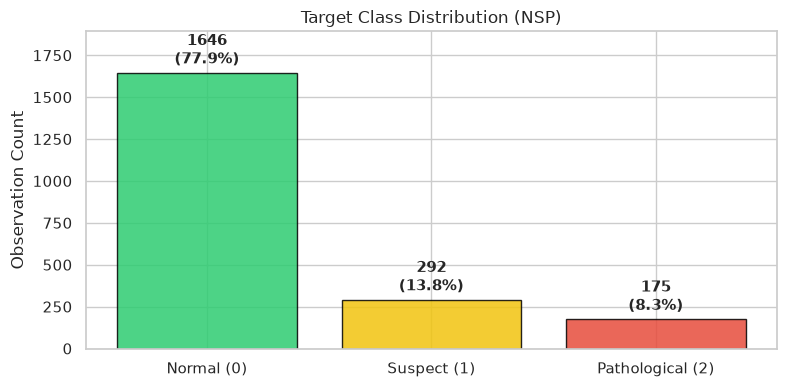

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
target_counts = y.value_counts().sort_index()
target_labels = ["Normal (0)", "Suspect (1)", "Pathological (2)"]
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]

bars = ax.bar(target_labels, target_counts, color=colors, edgecolor="black", alpha=0.85)

# Annotate count & percentage on bars
total = len(y)
for bar in bars:
    height = bar.get_height()
    pct = (height / total) * 100
    ax.annotate(f"{height}\n({pct:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontweight="bold")

ax.set_title("Target Class Distribution (NSP)")
ax.set_ylabel("Observation Count")
ax.set_ylim(0, max(target_counts) * 1.15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9182/2176065291.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X["ASTV"], palette=colors, ax=axes[0])
/tmp/ipykernel_9182/2176065291.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(target_labels)


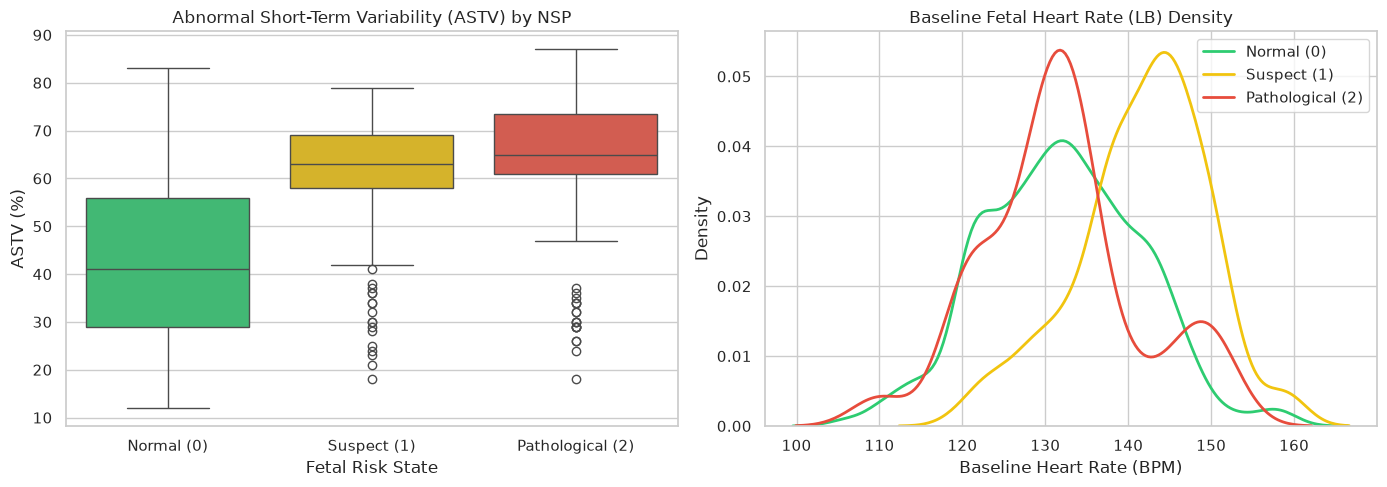

In [4]:
# Key diagnostic features: ASTV (Abnormal Short-Term Variability) and LB (Baseline Heart Rate)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ASTV Boxplot across NSP
sns.boxplot(x=y, y=X["ASTV"], palette=colors, ax=axes[0])
axes[0].set_xticklabels(target_labels)
axes[0].set_title("Abnormal Short-Term Variability (ASTV) by NSP")
axes[0].set_xlabel("Fetal Risk State")
axes[0].set_ylabel("ASTV (%)")

# Plot 2: Baseline Heart Rate Density
for idx, label in enumerate(target_labels):
    sns.kdeplot(X.loc[y == idx, "LB"], ax=axes[1], label=label, color=colors[idx], linewidth=2)

axes[1].set_title("Baseline Fetal Heart Rate (LB) Density")
axes[1].set_xlabel("Baseline Heart Rate (BPM)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

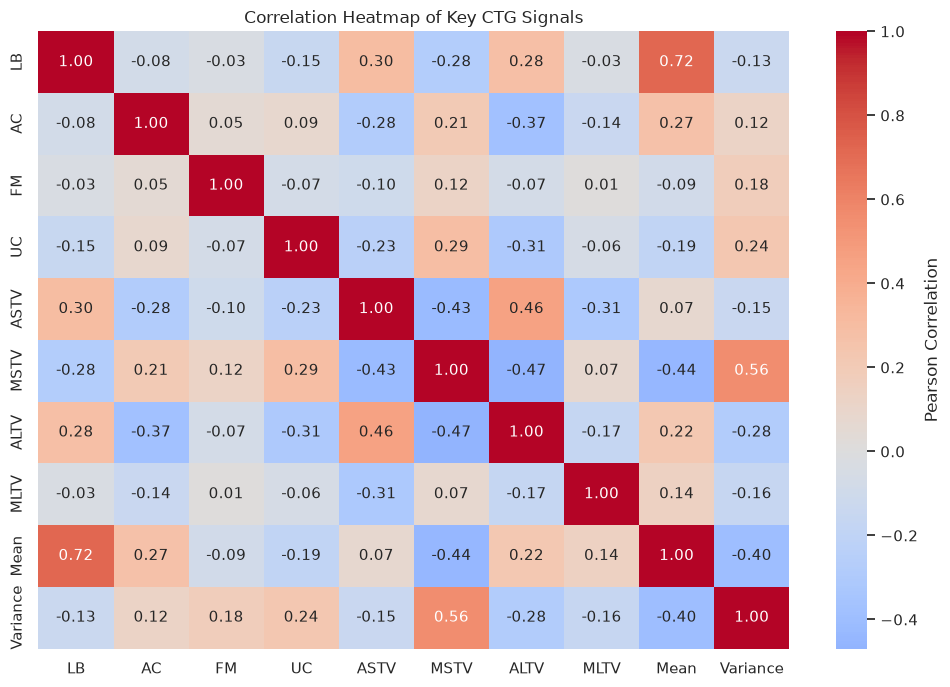

In [5]:
# Correlation matrix of key CTG signals
key_features = ["LB", "AC", "FM", "UC", "ASTV", "MSTV", "ALTV", "MLTV", "Mean", "Variance"]
corr_matrix = X[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={'label': 'Pearson Correlation'})
ax.set_title("Correlation Heatmap of Key CTG Signals")
plt.tight_layout()
plt.show()

## 3. Feature Engineering & Leak-Free Pipeline

We define domain-informed features derived from clinical CTG interpretation:
* **FHR Range & Mean Deviation:** Measures baseline centering and extreme spreads.
* **Variability Ratios:** Combines Short-Term (`ASTV`) and Long-Term (`ALTV`) variability.
* **Weighted Deceleration Burden:** Severe and Prolonged decelerations are weighted higher than Late decelerations.
* **Skewness Transforms:** $\log(1 + x)$ transforms applied to highly skewed count variables.

In [6]:
def transform_ctg_features(data: pd.DataFrame) -> pd.DataFrame:
    """Calculates clinical CTG ratios and log transforms safely per batch."""
    transformed = data.copy()

    # Heart Rate Spreads & Centering
    transformed["FHR_range"] = transformed["Max"] - transformed["Min"]
    transformed["FHR_mean_deviation"] = transformed["Mean"] - transformed["LB"]
    transformed["heart_rate_center_offset"] = transformed["Mode"] - transformed["LB"]

    # Short-Term vs Long-Term Variability Ratios
    transformed["variability_balance"] = transformed["ASTV"] / (
        transformed["ASTV"] + transformed["ALTV"] + 1e-6
    )

    # Activity & Contraction Ratios
    transformed["activity_contraction_ratio"] = transformed["AC"] / (
        transformed["UC"] + 1e-6
    )

    # Clinical Deceleration Burden
    transformed["deceleration_severity_score"] = (
        (transformed["DL"] * 1.0) + (transformed["DS"] * 3.0) + (transformed["DP"] * 2.0)
    )

    # Histogram Asymmetry
    transformed["histogram_asymmetry"] = (transformed["Mean"] - transformed["Mode"]) / (
        transformed["Width"] + 1e-6
    )

    # Log1p Transforms for Skewed Counts
    for column in count_cols:
        if column in transformed.columns:
            transformed[f"{column}_log1p"] = np.log1p(transformed[column].clip(lower=0))

    return transformed.replace([np.inf, -np.inf], np.nan)

# Construct scikit-learn Pipeline with LightGBM
model_pipeline = Pipeline(
    steps=[
        ("feature_engineering", FunctionTransformer(transform_ctg_features, validate=False)),
        (
            "classifier",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.03,
                num_leaves=31,
                class_weight="balanced",  # Handles imbalanced class proportions
                random_state=42,
                verbose=-1,
                n_jobs=-1,
            ),
        ),
    ]
)

## 4. Model Training & Evaluation

We split the clean dataset into an **80% Training set** and a **20% Stratified Hold-out Test set**. The test set remains completely unseen during training to ensure valid evaluation without data leakage.

In [7]:
# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Pipeline
print("Training LightGBM pipeline...")
model_pipeline.fit(X_train, y_train)

# Evaluate on Unseen Hold-out Test Set
y_pred = model_pipeline.predict(X_test)
y_probs = model_pipeline.predict_proba(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"\n Final Hold-Out Test Accuracy: {test_acc * 100:.2f}%\n")

# Detailed Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Normal", "Suspect", "Pathological"]))

Training LightGBM pipeline...

 Final Hold-Out Test Accuracy: 96.45%

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       330
     Suspect       0.96      0.79      0.87        58
Pathological       0.94      0.97      0.96        35

    accuracy                           0.96       423
   macro avg       0.96      0.92      0.94       423
weighted avg       0.96      0.96      0.96       423



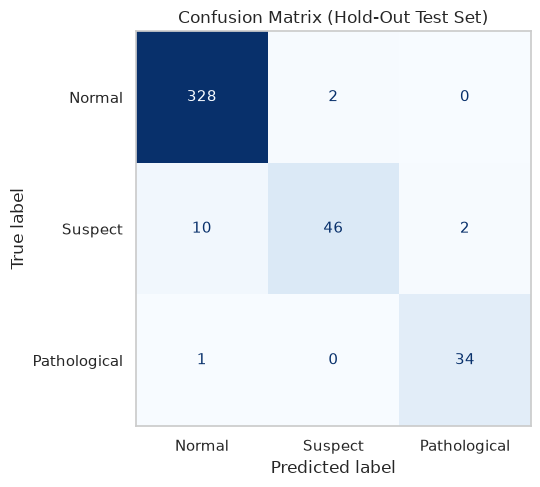

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Suspect", "Pathological"])
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix (Hold-Out Test Set)")
plt.grid(False)
plt.tight_layout()
plt.show()

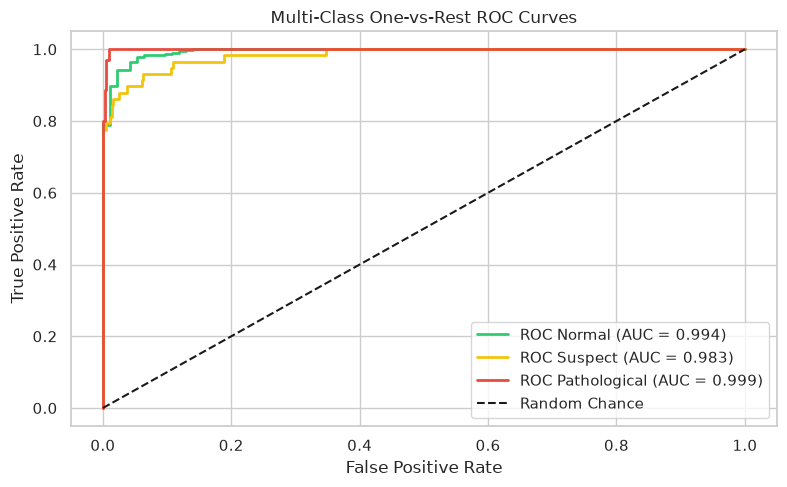

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, color, label in zip(range(3), colors, ["Normal", "Suspect", "Pathological"]):
    fpr, tpr, _ = roc_curve(y_test == i, y_probs[:, i])
    auc = roc_auc_score(y_test == i, y_probs[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"ROC {label} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Multi-Class One-vs-Rest ROC Curves")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Model Serialization & Prediction API

We verify the prediction API function and save the trained LightGBM pipeline artifact using `joblib`.

In [10]:
def predict_fetal_health(new_measurements: pd.DataFrame) -> pd.DataFrame:
    """Production inference API for raw CTG measurements."""
    risk_labels = {0: "Normal", 1: "Suspect", 2: "Pathological"}
    preds = model_pipeline.predict(new_measurements[X.columns])
    probs = model_pipeline.predict_proba(new_measurements[X.columns])

    return pd.DataFrame(
        {
            "predicted_nsp_code": preds + 1,  # Map back to 1-3 scale
            "risk_label": [risk_labels[p] for p in preds],
            "confidence": probs.max(axis=1),
            "prob_normal": probs[:, 0],
            "prob_suspect": probs[:, 1],
            "prob_pathological": probs[:, 2],
        },
        index=new_measurements.index,
    )

# Test API on 3 sample observations
sample_predictions = predict_fetal_health(X_test.head(3))
print("Sample Clinical API Output:")
display(sample_predictions)

# Save pipeline to disk
model_path = Path.cwd() / "lightgbm_fetal_health_model.joblib"
joblib.dump(model_pipeline, model_path)
print(f"\nTrained model pipeline saved successfully to: {model_path}")

Sample Clinical API Output:


,predicted_nsp_code,risk_label,confidence,prob_normal,prob_suspect,prob_pathological
635,1,Normal,0.999546,0.999546,0.000438,0.000016
1578,1,Normal,0.999773,0.999773,0.000152,0.000075
816,3,Pathological,0.998908,0.000350,0.000742,0.998908



Trained model pipeline saved successfully to: /workspaces/CTG/Notebook/lightgbm_fetal_health_model.joblib
